In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [72]:
smd = pd.read_csv("./Social_Network_Ads.csv")
smd

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [73]:
smd = smd.iloc[::, 2::]
smd.sample(10)

,Age,EstimatedSalary,Purchased
386,49,39000,1
341,35,75000,0
273,39,106000,1
274,57,26000,1
251,37,52000,0
24,46,23000,1
88,26,81000,0
188,35,72000,0
177,25,22000,0
157,29,75000,0


In [74]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(smd.drop("Purchased", axis= 1), smd["Purchased"], test_size=0.3, random_state= 0)
x_train.shape, x_test.shape

((280, 2), (120, 2))

In [75]:
scaler = skl.preprocessing.StandardScaler()
#scaler.fit(x_train)
x_train_scallered = scaler.fit_transform(x_train)
x_test_scallered = scaler.transform(x_test)

In [76]:
x_train_scallered = pd.DataFrame(x_train_scallered, columns= x_train.columns)
x_test_scallered = pd.DataFrame(x_test_scallered, columns= x_train.columns)

In [77]:
np.round(x_train.describe(), 1)     # Befor transforming the data mean is not 0 adn std is also not 1

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [78]:
np.round(x_train_scallered.describe(), 1)   # After transforming the data mena is 0 adn std is 1

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


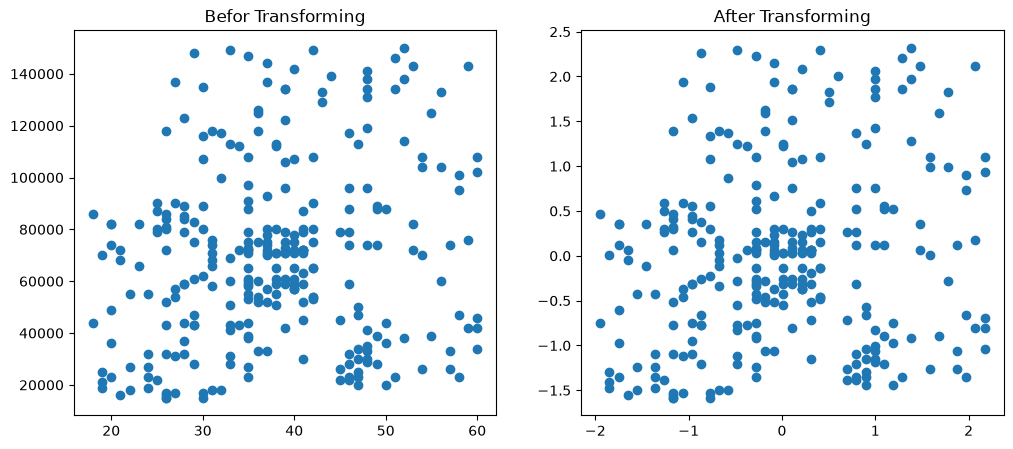

In [79]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(12, 5))

axis_1.scatter(x_train["Age"], x_train["EstimatedSalary"])
axis_1.set_title("Befor Transforming")

axis_2.scatter(x_train_scallered["Age"], x_train_scallered["EstimatedSalary"])
axis_2.set_title("After Transforming")

plt.show()

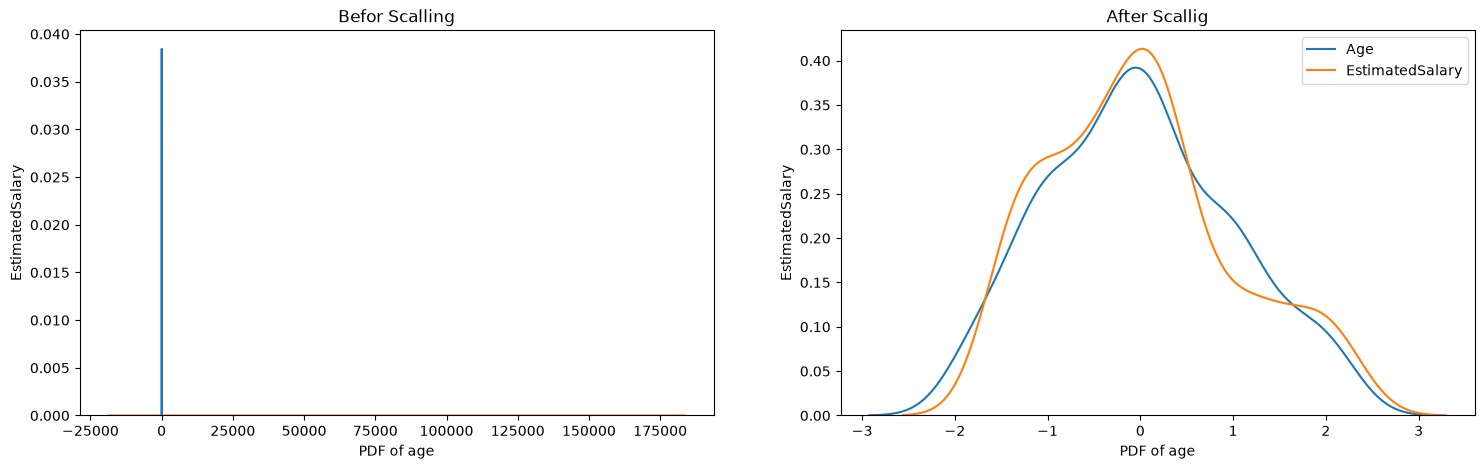

In [80]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(18, 5))

sns.kdeplot(x_train["Age"], ax= axis_1)
sns.kdeplot(x_train["EstimatedSalary"], ax= axis_1)
axis_1.set_title("Befor Scalling")
axis_1.set_xlabel("PDF of age")
axis_1.set_ylabel("EstimatedSalary")
plt.legend(["Age", "EstimatedSalary"])

sns.kdeplot(x_train_scallered["Age"], ax= axis_2)
sns.kdeplot(x_train_scallered["EstimatedSalary"], ax= axis_2)
axis_2.set_title("After Scallig")
axis_2.set_xlabel("PDF of age")
axis_2.set_ylabel("EstimatedSalary")
plt.legend(["Age", "EstimatedSalary"])

plt.show()

# Comparison Distribution

Distribution remain the same just the range changes

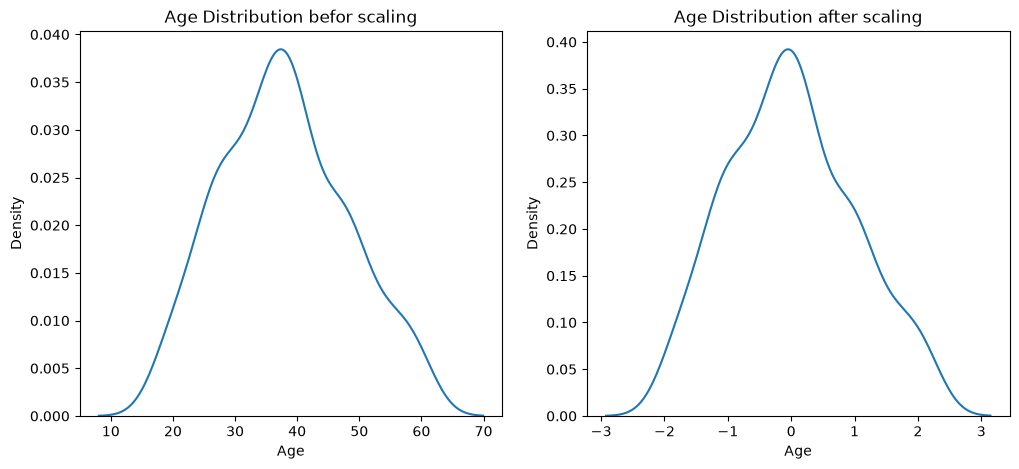

In [81]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(x_train["Age"], ax= axis_1)
axis_1.set_title("Age Distribution befor scaling")

sns.kdeplot(x_train_scallered["Age"], ax= axis_2)
axis_2.set_title("Age Distribution after scaling")

plt.show()

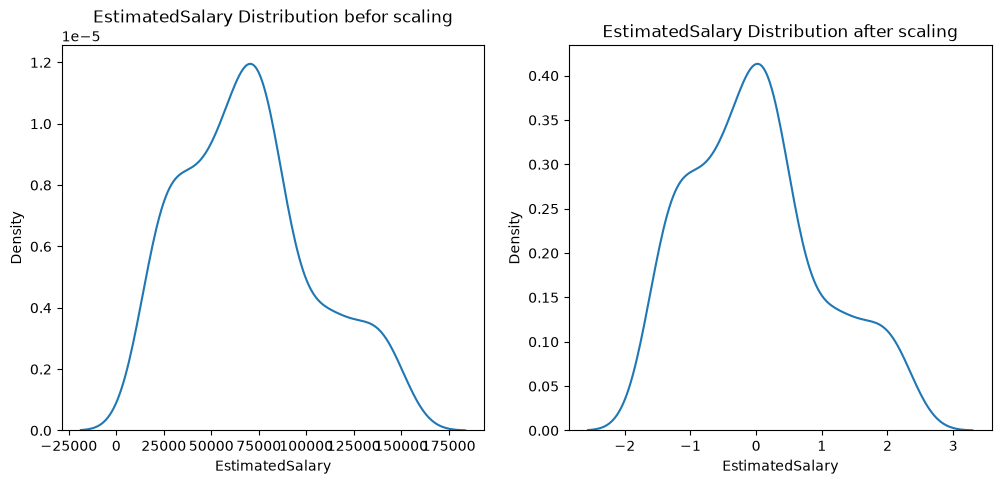

In [82]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(x_train["EstimatedSalary"], ax= axis_1)
axis_1.set_title("EstimatedSalary Distribution befor scaling")

sns.kdeplot(x_train_scallered["EstimatedSalary"], ax= axis_2)
axis_2.set_title("EstimatedSalary Distribution after scaling")

plt.show()

# Logistic Regression

In [99]:
logisticRegression = skl.linear_model.LogisticRegression()  # C=10, random_state=0
logisticRegression_scaled = skl.linear_model.LogisticRegression()

In [100]:
logisticRegression.fit(x_train, y_train)
logisticRegression_scaled.fit(x_train_scallered, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [101]:
y_predictions = logisticRegression.predict(x_test)
y_predictions_scaled = logisticRegression_scaled.predict(x_test_scallered)

In [102]:
print(f"Actual : {skl.metrics.accuracy_score(y_test, y_predictions)}")
print(f"Scalled : {skl.metrics.accuracy_score(y_test, y_predictions_scaled)}")

Actual : 0.875
Scalled : 0.8666666666666667


# Decision Tree

In [103]:
decisionTree = skl.tree.DecisionTreeClassifier()
decisionTree_scalled = skl.tree.DecisionTreeClassifier()

In [104]:
decisionTree.fit(x_train, y_train)
decisionTree_scalled.fit(x_train_scallered, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [105]:
decisionTree = logisticRegression.predict(x_test)
decisionTree_scalled = logisticRegression_scaled.predict(x_test_scallered)

In [107]:
print(f"Actual : {skl.metrics.accuracy_score(y_test, y_predictions)}")
print(f"Scalled : {skl.metrics.accuracy_score(y_test, y_predictions_scaled)}")

Actual : 0.875
Scalled : 0.8666666666666667


# IF DATA HAS OUTLIERS

In [108]:
smd.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [111]:
outliers = pd.DataFrame({
    "Age": [5, 90, 95], 
    "EstimatedSalary": [1000, 250000, 350000], 
    "Purchased": [0, 1, 1]
})

smd_withOutliers = pd.concat([smd, outliers], ignore_index=True)

smd_withOutliers.tail(5)

,Age,EstimatedSalary,Purchased
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1
402,95,350000,1


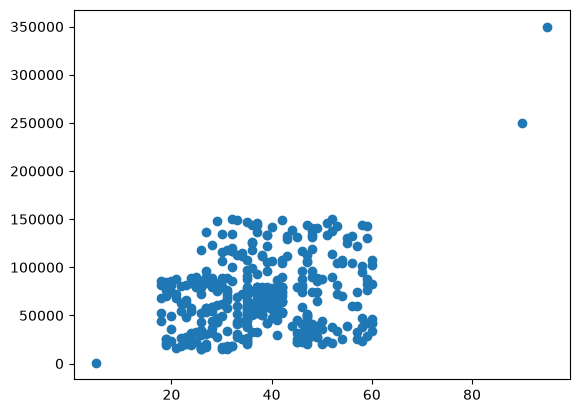

In [112]:
plt.scatter(smd_withOutliers["Age"], smd_withOutliers["EstimatedSalary"])

In [114]:
x_train_o, x_test_o, y_train_o, y_test_o = skl.model_selection.train_test_split(smd_withOutliers.drop("Purchased", axis= 1), smd_withOutliers["Purchased"], test_size=0.3, random_state= 0)
scaler_o = skl.preprocessing.StandardScaler()
scaler_o.fit(x_train_o)
x_train_o_scalled = scaler_o.transform(x_train_o)
x_test_o_scalled = scaler_o.transform(x_test_o)

x_train_o_scalled = pd.DataFrame(x_train_o_scalled, columns= x_train_o.columns)
x_test_o_scalled = pd.DataFrame(x_test_o_scalled, columns= x_test_o.columns)

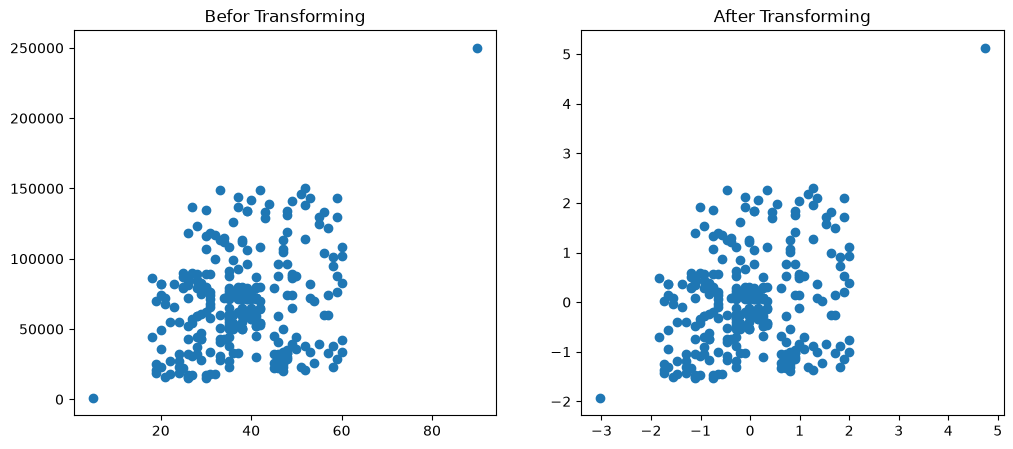

In [115]:
fig, (axis_1, axis_2) = plt.subplots(ncols=2, figsize=(12, 5))

axis_1.scatter(x_train_o["Age"], x_train_o["EstimatedSalary"])
axis_1.set_title("Befor Transforming")

axis_2.scatter(x_train_o_scalled["Age"], x_train_o_scalled["EstimatedSalary"])
axis_2.set_title("After Transforming")

plt.show()